# Побудова моделі


<h2>Мета</h2>

Ознайомитись з різновидами регресійних моделей. Після завершення цієї лабораторної роботи ви зможете:

* Будувати регресійні моделі кількох видів
* Оцінювати якість моделі візуально
* Оцінювати якість моделі за допомогою числових мір, без використання тестової вибірки
* Виконувати прогнозування відгуку, використовуючи побудовану модель



<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>

1. Скачати дані з фінального файлу першої роботи з виправленими помилками та заповненими пропусками. Записати дані у dataframe. В попередній роботі ви визначили ознаки, що можуть бути предикторами для 'CO2 emission'. Побудуйте моделі лінійної регресії для кожного з цих предикторів.
2. Побудуйте модель множинної лінійної регресії для всіх доречних предикторів разом.
3. Побудуйте кілька поліноміальних моделей другого порядку.
4. Побудуйте візуалізації для оцінки всіх моделей.
5. Порахуйте значення R^2 та MSE для оцінки якості кожної моделі. Оберіть найкращу модель.


<a name="task1"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>



Зчитую дані з файлу у датафрейм


In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
FILE_NAME = 'clean_data2.csv'
df = pd.read_csv(FILE_NAME, sep=',', encoding='utf-8');

<p>З попередньої роботи знаємо, що хорошими показниками для 'CO2 emission' можуть бути:</p>
<ul>
    <li>Population</li>
    <li>Area</li>
</ul>

In [2]:
def plot_scatter(x, y, x_label, y_label, title):
    plt.figure(figsize=(8, 4))
    plt.scatter(x, y, alpha=0.4)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.xlim(0,)
    plt.ylim(0,)
    plt.show()

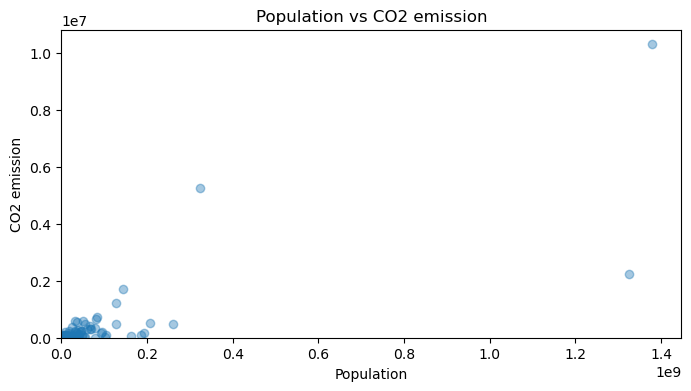

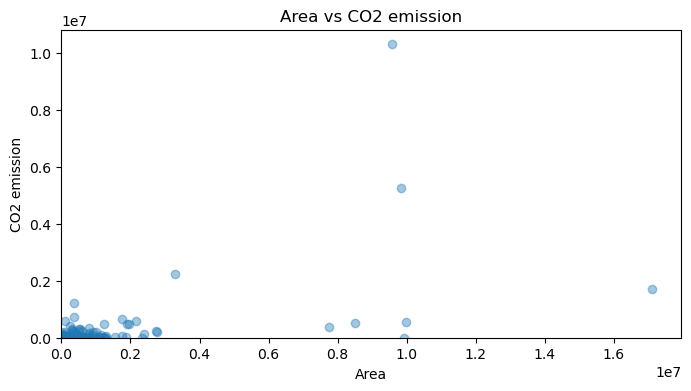

In [3]:
plot_scatter(df['Population'], df['CO2 emission'], 'Population', 'CO2 emission', 'Population vs CO2 emission')
plot_scatter(df['Area'], df['CO2 emission'], 'Area', 'CO2 emission', 'Area vs CO2 emission')

Розробимо моделі, використовуючи ці ознаки як змінні-предиктори.
<p>Створюю об’єкт лінійної регресії та навчаю першу модель 😀</p>

In [4]:
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()

X1 = df[['Population']] # предиктор
Y = df['CO2 emission'] # прогнозуємо (відгук)

model1.fit(X1, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Знаходжу коефіцієнти моделі


In [5]:
print(f'Коефіцієнт регресії для Population: {model1.coef_[0]:.4f}')
print(f'Вільний член (intercept(a)): {model1.intercept_:.4f}')

Коефіцієнт регресії для Population: 0.0048
Вільний член (intercept(a)): -8616.6423


Отримали кінцеву лінійну модель зі структурою:
$$
Yhat1 = a + b  X
$$

Підставляючи фактичні значення, маємо:

$$
Yhat1 =  0.0048X -8616.6423
$$

<p> Якщо населення збільшується на 1 одиницю, то викиди CO2 збільшуються в середньому на 0.0048 одиниць </p>

Створюю об’єкт лінійної регресії та навчаю другу модель


In [6]:
model2 = LinearRegression()

X2 = df[['Area']]
model2.fit(X2, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Знаходжу коефіцієнти моделі


In [8]:
print(f'Коефіцієнт регресії для Area: {model2.coef_[0]:.4f}')
print(f'Вільний член (intercept(a)): {model2.intercept_:.4f}')

Коефіцієнт регресії для Area: 0.2314
Вільний член (intercept(a)): 3646.0875


Отримали кінцеву лінійну модель зі структурою:
$$
Yhat2 = a + b  X
$$

Підставляючи фактичні значення, маємо:


$$
Yhat2 =  3646.0875 + 0.2314X
$$

<p> Якщо площа збільшується на 1 одиницю, то викиди CO2 збільшуються в середньому на 0.2314 одиниць </p>

<a name="task2"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Побудуйте модель множинної лінійної регресії для всіх доречних предикторів разом.</p>
</div>

<p>Перевірю на мультиколінеарність</p>

In [9]:
import statsmodels.api as sm    
from statsmodels.stats.outliers_influence import variance_inflation_factor

X1_1 = sm.add_constant(df[['Population', 'Area']])

vif = [variance_inflation_factor(exog=X1_1.values, exog_idx=i) for i in range(X1_1.shape[1])]

pd.DataFrame({'coef_name' : X1_1.columns, 'vif' : vif})

,coef_name,vif
0,const,1.133155
1,Population,1.217885
2,Area,1.217885


<p> VIF усіх змінних близький до 1, мультиколінеарності немає. Коефіцієнти регресії стабільні та надійні. </p>

Створюю об’єкт лінійної регресії та навчаю множинну лінійну модель із структурою
$$
Yhat3 = a + b_1 X_1 + b_2 X_2
$$

In [10]:
model3 = LinearRegression()
Z = df[['Population', 'Area']]
model3.fit(Z, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Знаходжу коефіцієнти моделі


In [11]:
print(f'Коефіцієнт регресії для Population: {model3.coef_[0]:.4f}')
print(f'Коефіцієнт регресії для Area: {model3.coef_[1]:.4f}')
print(f'Вільний член (intercept(a)): {model3.intercept_:.4f}')

Коефіцієнт регресії для Population: 0.0042
Коефіцієнт регресії для Area: 0.1081
Вільний член (intercept(a)): -57895.5696


Підставляючи фактичні значення, маємо:

$$
Yhat3 = 0.0042X_1 + 0.1081X_2 - 57895.5696
$$

<a name="task3"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудуйте кілька поліноміальних моделей другого порядку.</p>
</div>

Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat4 = a + b_1 X_1 + b_2 X_1^2  
$$

In [12]:
import numpy as np
Y = df['CO2 emission']
X1_1 = df['Population']

f1 = np.polyfit(X1_1, Y, 2)
p1 = np.poly1d(f1)

print(p1)

            2
-3.855e-13 x + 0.005331 x - 1.776e+04


Знаходжу коефіцієнти моделі


In [13]:
print(f'Вільний член (intercept(a)): {p1[0]:.4f}')
print(f'Коефіцієнт при x (slope(b1)): {p1[1]:.4f}')
print(f'Коефіцієнт при x^2 (slope(b2)): {p1[2]}')

Вільний член (intercept(a)): -17763.3122
Коефіцієнт при x (slope(b1)): 0.0053
Коефіцієнт при x^2 (slope(b2)): -3.8547541015656225e-13


Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat5 = a + b_1 X_2 + b_2 X_2^2
$$

In [14]:
X2_2 = df['Area']

f2 = np.polyfit(X2_2, Y, 2)
p2 = np.poly1d(f2)

print(p2)

            2
-1.292e-08 x + 0.3826 x - 4.305e+04


Знаходжу коефіцієнти моделі


In [15]:
print(f'Вільний член (intercept(a)): {p2[0]:.4f}')
print(f'Коефіцієнт при x (slope(b1)): {p2[1]:.4f}')
print(f'Коефіцієнт при x^2 (slope(b2)): {p2[2]}')

Вільний член (intercept(a)): -43047.9532
Коефіцієнт при x (slope(b1)): 0.3826
Коефіцієнт при x^2 (slope(b2)): -1.2919224689344129e-08


Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat6 = a + b_1 X_1 + b_2 X_2 + b_3 X_1 X_2 + b_4 X_1^2 + b_5 X_2^2
$$

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('model', LinearRegression())            
])

Z = df[['Population', 'Area']]
pipeline.fit(Z, Y)

,steps,"[('poly', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


Знаходжу коефіцієнти моделі


In [17]:
print(f'Вільний член (intercept(a)): {pipeline.named_steps["model"].intercept_:.4f}')
print(f'Коефіцієнти при x (slope(b1, b2, b3, b4, b5)): {pipeline.named_steps["model"].coef_}')

Вільний член (intercept(a)): 2635.9652
Коефіцієнти при x (slope(b1, b2, b3, b4, b5)): [ 2.26789851e-03  3.25163869e-02 -3.08923622e-12  1.01227521e-09
 -4.59415747e-09]


<a name="task4"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудуйте візуалізації для оцінки всіх моделей.</p>
</div>

Для простої лінійної регресії чудовим способом візуалізації відповідності моделі є використання графіків регресії. Цей графік покаже комбінацію розсіяних точок даних (діаграма розсіювання, scatterplot) та підігнану лінію лінійної регресії, що проходить через дані.

Таким способом візуалізую перші моделі.


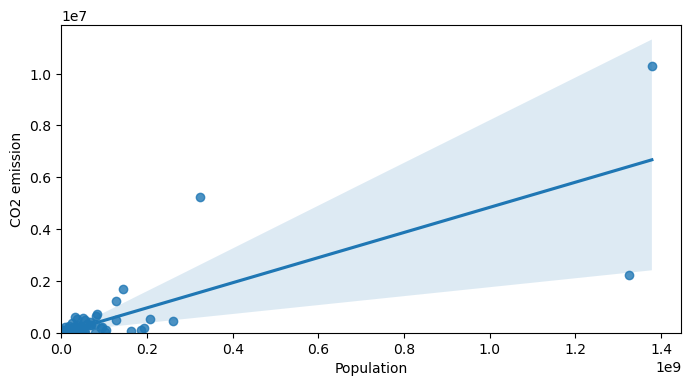

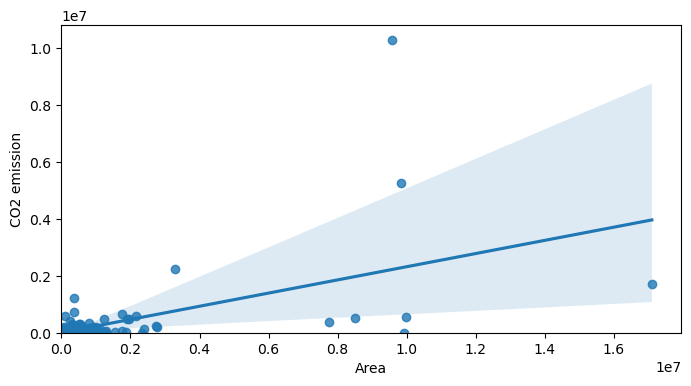

In [18]:
import seaborn as sns
%matplotlib inline

plt.figure(figsize=(8, 4))
sns.regplot(x=X1, y=Y)
plt.xlim(0,)
plt.ylim(0,)
plt.show()

plt.figure(figsize=(8, 4))
sns.regplot(x=X2, y=Y)
plt.xlim(0,)
plt.ylim(0,)
plt.show()

Для візуалізації дисперсії даних використаю діаграми залишків - по ній зможу прийняти рішення про необхідність ускладнення моделі.


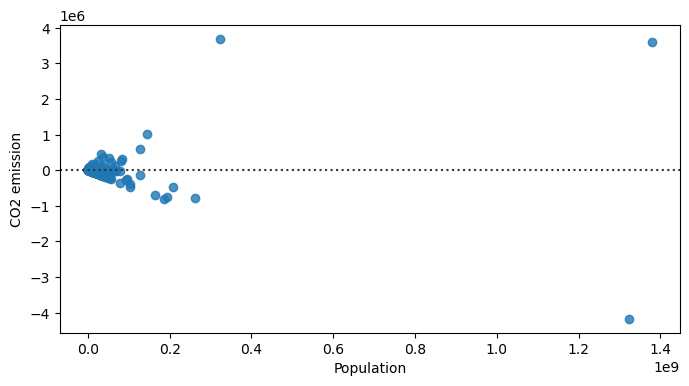

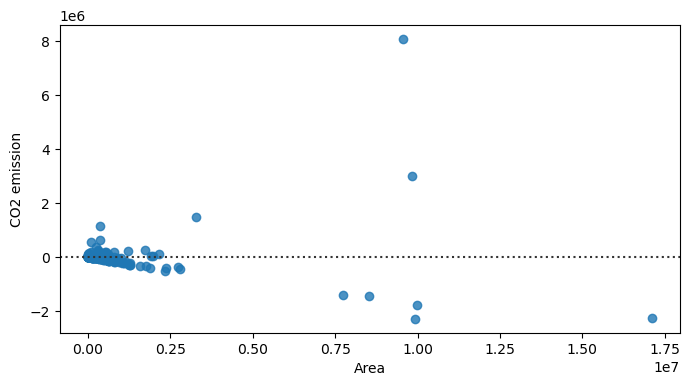

In [19]:
plt.figure(figsize=(8, 4))
sns.residplot(x=X1, y=Y)
plt.show()


plt.figure(figsize=(8, 4))
sns.residplot(x=X2, y=Y)
plt.show()

Для візуалізації моделі множинної лінійної регресії використаю діаграму розподілу.


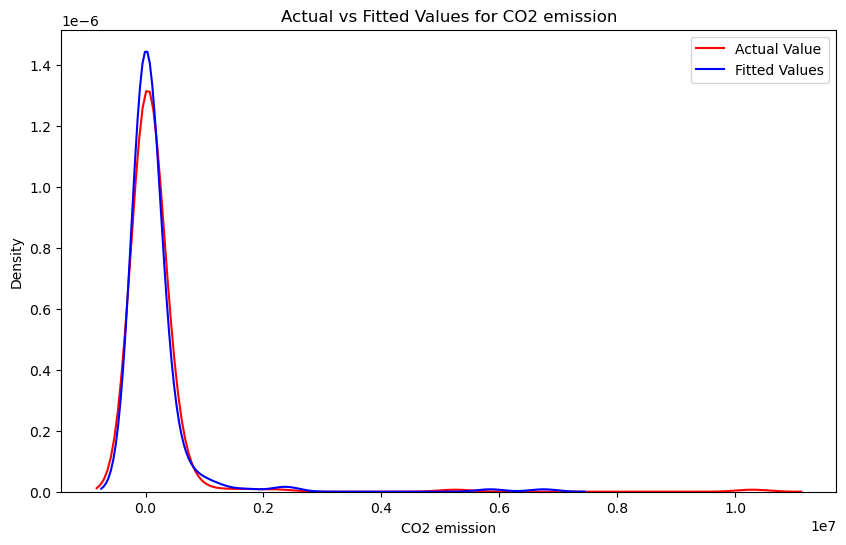

In [20]:
Y_hat = model3.predict(Z)

plt.figure(figsize=(10, 6))

sns.kdeplot(Y.squeeze(), color="r", label="Actual Value")
sns.kdeplot(Y_hat.squeeze(), color="b", label="Fitted Values")

plt.title("Actual vs Fitted Values for CO2 emission")
plt.xlabel("CO2 emission")
plt.ylabel("Density")

plt.legend()
plt.show()

Для візуалізації поліноміальних моделей з одним предиктором використаю функцію <code>poly1d</code>. Зручно розміщувати всі моделі на одному графіку для обрання найкращої.


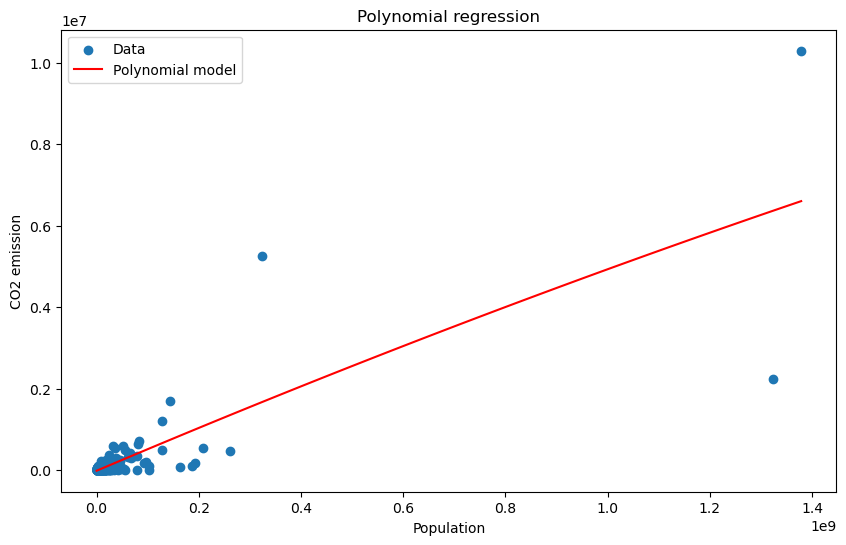

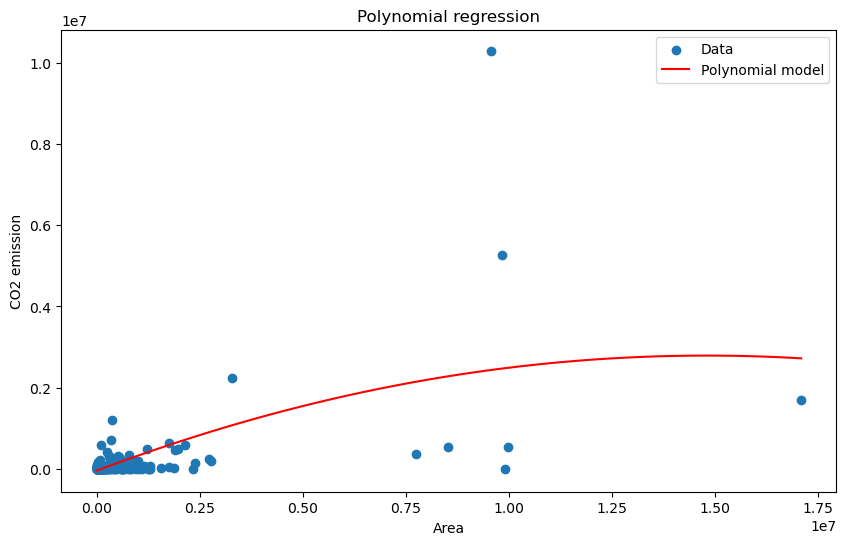

In [21]:
line = np.linspace(min(X1_1), max(X1_1), 100)
y_curve = p1(line)

plt.figure(figsize=(10, 6))
plt.scatter(X1_1, Y, label='Data')
plt.plot(line, y_curve, color='red', label='Polynomial model')
plt.xlabel('Population')
plt.ylabel('CO2 emission')
plt.title('Polynomial regression')
plt.legend()
plt.show()

line = np.linspace(min(X2_2), max(X2_2), 100)
y_curve = p2(line)

plt.figure(figsize=(10, 6))
plt.scatter(X2_2, Y, label='Data')
plt.plot(line, y_curve, color='red', label='Polynomial model')
plt.xlabel('Area')
plt.ylabel('CO2 emission')
plt.title('Polynomial regression')
plt.legend()
plt.show()

Для візуалізації поліноміальних моделей з кількома предикторами використаю діаграму розподілу або діаграму залишків


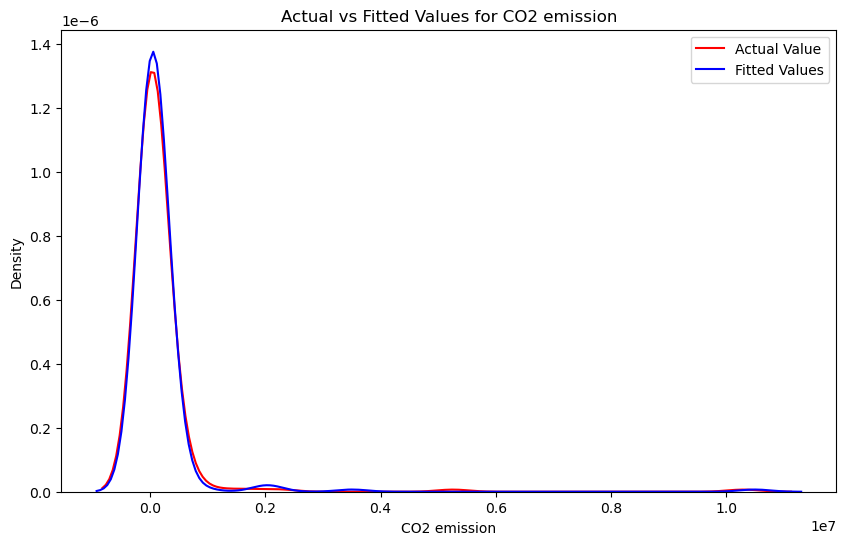

In [22]:
Y_hat = pipeline.predict(Z)

plt.figure(figsize=(10, 6))

sns.kdeplot(Y.squeeze(), color="r", label="Actual Value")
sns.kdeplot(Y_hat.squeeze(), color="b", label="Fitted Values")

plt.title("Actual vs Fitted Values for CO2 emission")
plt.xlabel("CO2 emission")
plt.ylabel("Density")

plt.legend()
plt.show()

<a name="task5"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Порахуйте значення R^2 та MSE для оцінки якості кожної моделі. Оберіть найкращу модель.</p>
</div>

Значення R^2 отримую безпосередньо з моделі <code>.score(X, Y)</code>, а для розрахунку MSE спочатку формую прогнозовані значення <code>.predict(X)</code> і порівнюю їх з фактичними


In [23]:
from sklearn.metrics import mean_squared_error
X1 = df[['Population']]
X2 = df[['Area']]
Y = df['CO2 emission'] 
Z = df[['Population', 'Area']]

Модель 1:
$$
Yhat1 = a + b  X
$$


In [24]:
print('Коефіцієнт детермінації (R^2): ', model1.score(X1, Y));
Y_hat1 = model1.predict(X1)
ms = mean_squared_error(Y, Y_hat1)
print('Середньоквадратична помилка: ', ms)

Коефіцієнт детермінації (R^2):  0.6465629436013779
Середньоквадратична помилка:  231226245784.79776


Модель 2:
$$
Yhat2 = a + b  X
$$

In [25]:
print('Коефіцієнт детермінації (R^2): ', model2.score(X2, Y));
Y_hat2 = model2.predict(X2)
ms = mean_squared_error(Y, Y_hat2)
print('Середньоквадратична помилка: ', ms)

Коефіцієнт детермінації (R^2):  0.30436950697780796
Середньоквадратична помилка:  455096669811.3789


Модель 3:
$$
Yhat3 = a + b_1 X_1 + b_2 X_2
$$

In [26]:
print('Коефіцієнт детермінації (R^2): ', model3.score(Z, Y));
Y_hat3 = model3.predict(Z)
ms = mean_squared_error(Y, Y_hat3)
print('Середньоквадратична помилка: ', ms)

Коефіцієнт детермінації (R^2):  0.701087946957023
Середньоквадратична помилка:  195554797081.0436


Модель 4:
$$
Yhat4 = a + b_1 X_1 + b_2 X_1^2  
$$

In [27]:
# Імпортуємо функцію r2_score з модуля metrics, оскільки використовуємо іншу функцію
from sklearn.metrics import r2_score
print('Коефіцієнт детермінації (R^2): ', r2_score(Y, p1(X1)));
ms = mean_squared_error(Y, p1(X1))
print('Середньоквадратична помилка: ', ms)

Коефіцієнт детермінації (R^2):  0.6470806677512729
Середньоквадратична помилка:  230887539332.36133


Модель 5:
$$
Yhat5 = a + b_1 X_2 + b_2 X_2^2
$$

In [28]:
print('Коефіцієнт детермінації (R^2): ', r2_score(Y, p2(X2)));
ms = mean_squared_error(Y, p2(X2))
print('Середньоквадратична помилка: ', ms)

Коефіцієнт детермінації (R^2):  0.32507007411676425
Середньоквадратична помилка:  441553906429.6055


Модель 6:
$$
Yhat6 = a + b_1 X_1 + b_2 X_2 + b_3 X_1 X_2 + b_4 X_1^2 + b_5 X_2^2
$$

In [29]:
print('Коефіцієнт детермінації (R^2): ', pipeline.score(Z,Y));
Y_hat = pipeline.predict(Z)
ms = mean_squared_error(Y, Y_hat)
print('Середньоквадратична помилка: ', ms)

Коефіцієнт детермінації (R^2):  0.9378856270451016
Середньоквадратична помилка:  40636580142.403885


<p>Тепер, коли ми візуалізували різні моделі та згенерували значення R-квадрат і MSE для побудованих моделей, як визначаємо хорошу модель?
<ul>
    <li><i>Що таке хороше значення R-квадрат?</i></li>
</ul>
</p>

<p>Під час порівняння моделей, <b>модель із вищим значенням R-квадрат краще підходить</b> для даних.<ul>
    <li><i>Що таке хороший MSE?</i></li>
</ul>
</p>

<p>Під час порівняння моделей <b>модель із найменшим значенням MSE краще підходить</b> для даних.</p>


<h4>Висновок</h4>
<p style="font-family: Arial, sans-serif; font-size: 16px, color: #333;"> Порівнюючи всі 6 моделей, роблю висновок, <strong> що модель 6 є найкращою моделлю для прогнозування CO2 emission на основі нашого набору даних.</strong> Вона має найвищий коефіцієнт детермінації R^2 (≈0.938), що свідчить про високу точність пояснення варіації даних, а також найменшу середньоквадратичну помилку (MSE ≈ 40,64 млрд), що гарантує мінімальні похибки прогнозів. Інші моделі мають нижчі значення R^2 і вищі MSE, тому вони не забезпечують такої точності прогнозування. Ця модель оптимально підходить для подальшого використання у передбаченні викидів CO2 на основі наших даних. </p>


<a name="task6"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Побудуйте та оцініть кілька поліноміальних моделей різних порядків.</p>
</div>

1. Побудуйте кілька поліноміальних моделей різних порядків.
2. Побудуйте візуалізації для оцінки всіх моделей, починаючи з лінійної (зручно розміщувати всі моделі на одному графіку для обрання найкращої).
3. Порахуйте значення R^2 та MSE для оцінки якості кожної моделі (теж доцільно побудувати графік залежності R^2 або MSE від порядку поліному моделі).
4. Оберіть найкращу модель, висновок обгрунтуйте.


In [30]:
X1 = df['Population']
Y = df['CO2 emission']

In [33]:
degrees = list(range(1, 5))

# Метрики
models = {}
mse_list = []
r2_list = []

for d in degrees:  # Поліноміальні моделі від 1-го до 4-го ступеня
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X1.values.reshape(-1, 1))
    
    model = LinearRegression()
    model.fit(X_poly, Y)
    
    models[d] = (poly, model)
    
    Y_pred = model.predict(X_poly)
    
    mse = mean_squared_error(Y, Y_pred)
    r2 = r2_score(Y, Y_pred)
    
    mse_list.append(mse)
    r2_list.append(r2)

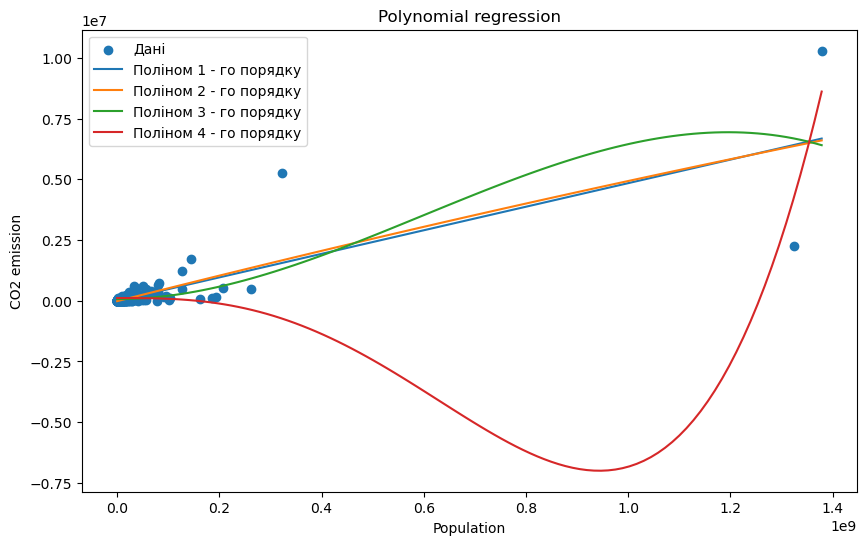

In [34]:
line = np.linspace(X1.min(), X1.max(), 100).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X1, Y, label='Дані')

for degree, (poly, model) in models.items():
    y_curve = model.predict(poly.transform(line))
    plt.plot(line, y_curve, label=f"Поліном {degree} - го порядку")

plt.xlabel('Population')
plt.ylabel('CO2 emission')
plt.title('Polynomial regression')
plt.legend()
plt.show()

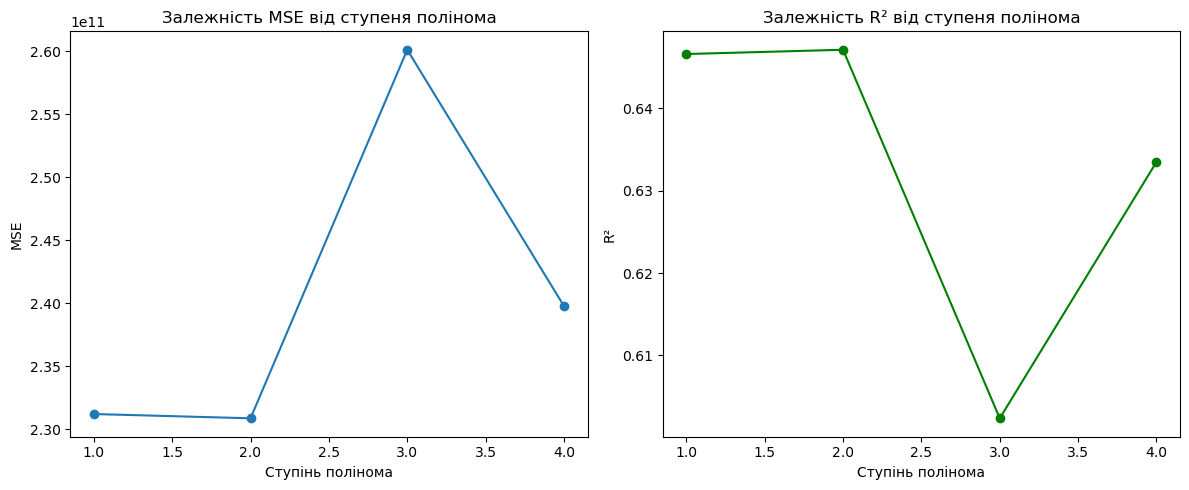

In [35]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(degrees, mse_list, marker='o')
plt.xlabel('Ступінь полінома')
plt.ylabel('MSE')
plt.title('Залежність MSE від ступеня полінома')

plt.subplot(1,2,2)
plt.plot(degrees, r2_list, marker='o', color='green')
plt.xlabel('Ступінь полінома')
plt.ylabel('R²')
plt.title('Залежність R² від ступеня полінома')

plt.tight_layout()
plt.show()

<h4>Висновок</h4>
<p style="font-family: Arial, sans-serif; font-size: 16px, color: #333;"> Порівнюючи всі чотири  побудовані поліноміальні моделі, роблю висновок, <strong> що модель 2 є найкращою моделлю для прогнозування CO2 emission на основі даних про популяцію. </strong> Вона має найвищий коефіцієнт детермінації R^2 (≈0.6471), що свідчить про найбільш точне пояснення варіації викидів CO2 залежно від популяції, а також найменшу середньоквадратичну помилку (MSE ≈ 230,89 млрд), що гарантує мінімальні похибки прогнозів. Інші моделі показують меншу точність, тому вони менш ефективні для передбачення викидів CO2 на основі населення.</p>

<h2>Виконав студент групи ІП-45<br>Буряк Володимир</h2>